In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import (
    Adam,
    RMSprop
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import os

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
X_train_pad = np.load(
    "/content/drive/MyDrive/processed_data/X_train.npy"
)

X_val_pad = np.load(
    "/content/drive/MyDrive/processed_data/X_val.npy"
)

X_test_pad = np.load(
    "/content/drive/MyDrive/processed_data/X_test.npy"
)

y_train = np.load(
    "/content/drive/MyDrive/processed_data/y_train.npy"
)

y_val = np.load(
    "/content/drive/MyDrive/processed_data/y_val.npy"
)

y_test = np.load(
    "/content/drive/MyDrive/processed_data/y_test.npy"
)

In [5]:
print("Training:", X_train_pad.shape)
print("Validation:", X_val_pad.shape)
print("Testing:", X_test_pad.shape)

Training: (34998, 200)
Validation: (7502, 200)
Testing: (7500, 200)


In [6]:
VOCAB_SIZE = 20000

BASE_SEQUENCE_LENGTH = 200

BASE_EMBEDDING_DIM = 128

BASE_HIDDEN_UNITS = 64

BASE_DROPOUT = 0.3

BASE_BATCH_SIZE = 64

BASE_EPOCHS = 10

In [7]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    probabilities = model.predict(
        X_test,
        verbose=0
    ).flatten()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    print("\n", model_name)

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [8]:
#Build Baseline ANN
def build_baseline_ANN():

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GlobalAveragePooling1D(),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            0.3
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [9]:
#Train Baseline ANN
baseline_ANN = build_baseline_ANN()

baseline_history = baseline_ANN.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.7700 - loss: 0.4699 - val_accuracy: 0.8650 - val_loss: 0.3267
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8893 - loss: 0.2770 - val_accuracy: 0.8664 - val_loss: 0.3118
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.9156 - loss: 0.2225 - val_accuracy: 0.8720 - val_loss: 0.3048
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.9343 - loss: 0.1840 - val_accuracy: 0.8764 - val_loss: 0.3104
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9459 - loss: 0.1564 - val_accuracy: 0.8406 - val_loss: 0.3810


In [10]:
#Evaluate Baseline ANN
baseline_result = evaluate_model(

    baseline_ANN,

    X_test_pad,

    y_test,

    "Baseline ANN"
)


 Baseline ANN
Accuracy: 0.8465
Precision: 0.7958
Recall: 0.9323
F1 Score: 0.8587
ROC-AUC: 0.9401


In [11]:
os.makedirs(
    "saved_models",
    exist_ok=True
)

baseline_ANN.save(
    "saved_models/baseline_ANN.keras"
)

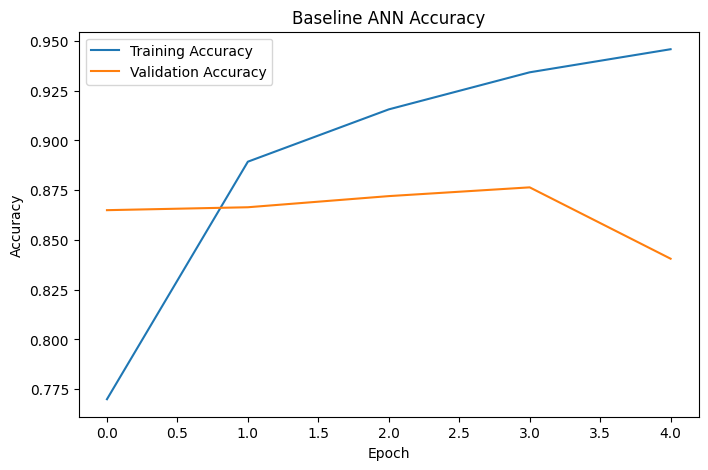

In [12]:
#Plot Baseline Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Baseline ANN Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [13]:
embedding_results = []

for embedding_dim in [64, 128, 256]:

    print(
        "\nTesting Embedding Dimension:",
        embedding_dim
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=embedding_dim,
            input_length=200
        ),

        GlobalAveragePooling1D(),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    val_accuracy = max(
        history.history["val_accuracy"]
    )

    embedding_results.append({

        "Embedding Dimension": embedding_dim,

        "Validation Accuracy": val_accuracy

    })


Testing Embedding Dimension: 64
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7668 - loss: 0.4808 - val_accuracy: 0.8400 - val_loss: 0.3583
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8860 - loss: 0.2813 - val_accuracy: 0.8679 - val_loss: 0.3083
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9150 - loss: 0.2232 - val_accuracy: 0.8759 - val_loss: 0.3042

Testing Embedding Dimension: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.7719 - loss: 0.4690 - val_accuracy: 0.8656 - val_loss: 0.3194
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.8911 - loss: 0.2739 - val_accuracy: 0.8547 - val_loss: 0.3243
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.9166 - loss: 0.2212 - val_accuracy: 0.8662 - val_loss: 0.3135

Testing Embedding Dimension: 256
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 47s 83ms/step - accuracy: 0.7907 - loss: 0.4397 - val_accuracy: 0.8484 - val_loss: 0.3372
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 

In [14]:
embedding_df = pd.DataFrame(
    embedding_results
)

embedding_df

,Embedding Dimension,Validation Accuracy
0,64,0.875900
1,128,0.866169
2,256,0.876033


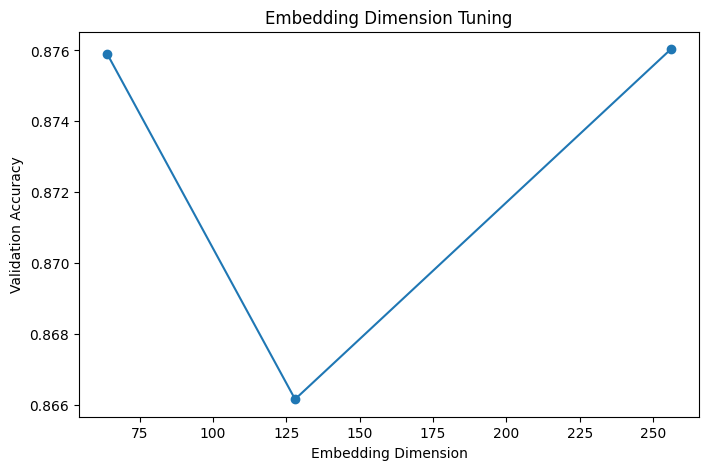

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    embedding_df["Embedding Dimension"],
    embedding_df["Validation Accuracy"],
    marker="o"
)

plt.title(
    "Embedding Dimension Tuning"
)

plt.xlabel(
    "Embedding Dimension"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.show()

In [16]:
hidden_results = []

for units in [32, 64, 128]:

    print(
        "\nTesting Hidden Units:",
        units
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

      GlobalAveragePooling1D(),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    hidden_results.append({

        "Hidden Units": units,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Hidden Units: 32
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.7776 - loss: 0.4661 - val_accuracy: 0.8519 - val_loss: 0.3404
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.8842 - loss: 0.2855 - val_accuracy: 0.8510 - val_loss: 0.3345
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.9143 - loss: 0.2258 - val_accuracy: 0.8627 - val_loss: 0.3274

Testing Hidden Units: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.7731 - loss: 0.4698 - val_accuracy: 0.8619 - val_loss: 0.3290
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8867 - loss: 0.2814 - val_accuracy: 0.8796 - val_loss: 0.2920
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9147 - loss: 0.2250 - val_accuracy: 0.8782 - val_loss: 0.3001

Testing Hidden Units: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.7788 - loss: 0.4633 - val_accuracy: 0.8555 - val_loss: 0.3334
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step -

In [17]:
hidden_df = pd.DataFrame(
    hidden_results
)

hidden_df

,Hidden Units,Validation Accuracy
0,32,0.862703
1,64,0.879632
2,128,0.872167


In [18]:
#Tune Dropout
dropout_results = []

for dropout_rate in [0.2, 0.3, 0.5]:

    print(
        "\nTesting Dropout:",
        dropout_rate
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GlobalAveragePooling1D(),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            dropout_rate
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    dropout_results.append({

        "Dropout": dropout_rate,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Dropout: 0.2
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.7803 - loss: 0.4599 - val_accuracy: 0.8688 - val_loss: 0.3193
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.8900 - loss: 0.2703 - val_accuracy: 0.8530 - val_loss: 0.3306
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9175 - loss: 0.2177 - val_accuracy: 0.8744 - val_loss: 0.3096

Testing Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.7735 - loss: 0.4738 - val_accuracy: 0.8372 - val_loss: 0.3584
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.8851 - loss: 0.2869 - val_accuracy: 0.8768 - val_loss: 0.2925
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9149 - loss: 0.2265 - val_accuracy: 0.8766 - val_loss: 0.2994

Testing Dropout: 0.5
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.7638 - loss: 0.4847 - val_accuracy: 0.8280 - val_loss: 0.3752
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy

In [19]:
#Display Dropout Results
dropout_df = pd.DataFrame(
    dropout_results
)

dropout_df

,Dropout,Validation Accuracy
0,0.2,0.874433
1,0.3,0.876833
2,0.5,0.874167


In [20]:
#Tune Recurrent Dropout
recurrent_results = []

for recurrent_dropout in [0.0, 0.2, 0.3]:

    print(
        "\nTesting Recurrent Dropout:",
        recurrent_dropout
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),


         GlobalAveragePooling1D(),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    recurrent_results.append({

        "Recurrent Dropout":
            recurrent_dropout,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Recurrent Dropout: 0.0
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - accuracy: 0.7719 - loss: 0.4685 - val_accuracy: 0.8482 - val_loss: 0.3423
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.8901 - loss: 0.2757 - val_accuracy: 0.8742 - val_loss: 0.2977
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.9176 - loss: 0.2214 - val_accuracy: 0.8743 - val_loss: 0.3049

Testing Recurrent Dropout: 0.2
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.7738 - loss: 0.4707 - val_accuracy: 0.8571 - val_loss: 0.3264
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.8886 - loss: 0.2780 - val_accuracy: 0.8755 - val_loss: 0.2943
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.9142 - loss: 0.2261 - val_accuracy: 0.8752 - val_loss: 0.2991

Testing Recurrent Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.7746 - loss: 0.4685 - val_accuracy: 0.8604 - val_loss: 0.3252
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 

In [21]:
recurrent_df = pd.DataFrame(
    recurrent_results
)

recurrent_df

,Recurrent Dropout,Validation Accuracy
0,0.0,0.874300
1,0.2,0.875500
2,0.3,0.877499


In [22]:
#Try Batch Normalization
batchnorm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),


     GlobalAveragePooling1D(),

    BatchNormalization(),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
batchnorm_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [24]:
batchnorm_history = batchnorm_model.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.8202 - loss: 0.3968 - val_accuracy: 0.8716 - val_loss: 0.3549
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.8962 - loss: 0.2553 - val_accuracy: 0.8502 - val_loss: 0.3402
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9177 - loss: 0.2019 - val_accuracy: 0.8638 - val_loss: 0.3389
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.9317 - loss: 0.1703 - val_accuracy: 0.8730 - val_loss: 0.3584
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.9408 - loss: 0.1449 - val_accuracy: 0.8664 - val_loss: 0.4007


In [25]:
learning_rate_results = []

for lr in [0.001, 0.0005, 0.0001]:

    print(
        "\nTesting Learning Rate:",
        lr
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

         GlobalAveragePooling1D(),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    optimizer = Adam(
        learning_rate=lr
    )

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    learning_rate_results.append({

        "Learning Rate": lr,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Learning Rate: 0.001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.7694 - loss: 0.4786 - val_accuracy: 0.8658 - val_loss: 0.3219
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.8821 - loss: 0.2910 - val_accuracy: 0.8716 - val_loss: 0.2979
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.9147 - loss: 0.2324 - val_accuracy: 0.8527 - val_loss: 0.3341

Testing Learning Rate: 0.0005
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - accuracy: 0.7358 - loss: 0.5395 - val_accuracy: 0.8460 - val_loss: 0.3734
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.8706 - loss: 0.3179 - val_accuracy: 0.8711 - val_loss: 0.3097
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.8995 - loss: 0.2563 - val_accuracy: 0.8623 - val_loss: 0.3197

Testing Learning Rate: 0.0001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.6395 - loss: 0.6818 - val_accuracy: 0.7534 - val_loss: 0.6554
Epoch

In [26]:
learning_rate_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_df

,Learning Rate,Validation Accuracy
0,0.0010,0.871634
1,0.0005,0.871101
2,0.0001,0.823514


In [27]:
optimizer_results = []

optimizers = {

    "Adam": Adam(
        learning_rate=0.0005
    ),

    "RMSprop": RMSprop(
        learning_rate=0.0005
    )
}


for optimizer_name, optimizer in optimizers.items():

    print(
        "\nTesting Optimizer:",
        optimizer_name
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        GlobalAveragePooling1D(),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    optimizer_results.append({

        "Optimizer": optimizer_name,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Optimizer: Adam
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.7546 - loss: 0.5259 - val_accuracy: 0.8522 - val_loss: 0.3602
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.8728 - loss: 0.3149 - val_accuracy: 0.8694 - val_loss: 0.3051
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9011 - loss: 0.2514 - val_accuracy: 0.8758 - val_loss: 0.2982

Testing Optimizer: RMSprop
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.5681 - loss: 0.6886 - val_accuracy: 0.6117 - val_loss: 0.6772
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.6637 - loss: 0.6377 - val_accuracy: 0.7247 - val_loss: 0.5775
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.7483 - loss: 0.5315 - val_accuracy: 0.7886 - val_loss: 0.4708


In [28]:
optimizer_df = pd.DataFrame(
    optimizer_results
)

optimizer_df

,Optimizer,Validation Accuracy
0,Adam,0.875766
1,RMSprop,0.788590


In [29]:
batch_results = []

for batch_size in [32, 64, 128]:

    print(
        "\nTesting Batch Size:",
        batch_size
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

      GlobalAveragePooling1D(),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.0005
        ),

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=batch_size,

        verbose=1
    )

    batch_results.append({

        "Batch Size": batch_size,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Batch Size: 32
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step - accuracy: 0.7776 - loss: 0.4744 - val_accuracy: 0.8608 - val_loss: 0.3265
Epoch 2/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.8873 - loss: 0.2841 - val_accuracy: 0.8786 - val_loss: 0.2900
Epoch 3/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step - accuracy: 0.9139 - loss: 0.2267 - val_accuracy: 0.8714 - val_loss: 0.3057

Testing Batch Size: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.7420 - loss: 0.5319 - val_accuracy: 0.8510 - val_loss: 0.3632
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8730 - loss: 0.3135 - val_accuracy: 0.8706 - val_loss: 0.3106
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.9032 - loss: 0.2503 - val_accuracy: 0.8779 - val_loss: 0.2921

Testing Batch Size: 128
Epoch 1/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7156 - loss: 0.5909 - val_accuracy: 0.8266 - val_loss: 0.4325
Epoch 2/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step

In [30]:
batch_df = pd.DataFrame(
    batch_results
)

batch_df

,Batch Size,Validation Accuracy
0,32,0.878566
1,64,0.877899
2,128,0.865369


In [31]:
optimized_ANN = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),

     GlobalAveragePooling1D(),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
optimized_optimizer = Adam(
    learning_rate=0.0005
)


optimized_ANN.compile(

    optimizer=optimized_optimizer,

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


optimized_ANN.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_22     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=2,

    restore_best_weights=True
)

In [34]:
learning_rate_scheduler = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=1,

    min_lr=0.00001
)

In [35]:
optimized_history = optimized_ANN.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping,
        learning_rate_scheduler
    ]
)
optimized_history = optimized_ANN.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping,
        learning_rate_scheduler
    ]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.7491 - loss: 0.5266 - val_accuracy: 0.8242 - val_loss: 0.3855 - learning_rate: 5.0000e-04
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.8741 - loss: 0.3102 - val_accuracy: 0.8715 - val_loss: 0.3080 - learning_rate: 5.0000e-04
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.9046 - loss: 0.2465 - val_accuracy: 0.8770 - val_loss: 0.2906 - learning_rate: 5.0000e-04
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9207 - loss: 0.2133 - val_accuracy: 0.8712 - val_loss: 0.3106 - learning_rate: 5.0000e-04
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.9397 - loss: 0.1737 - val_accuracy: 0.8796 - val_loss: 0.3017 - learning_rate: 2.5000e-04
Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9297 - loss: 0.1983 - val_accuracy: 0.8803 - val_loss: 0.2924 - learning_rate: 1.2500e-04
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/ste

In [36]:
optimized_ANN.save(
    "saved_models/optimized_ANN.keras"
)

print(
    "Optimized ANN saved successfully!"
)

Optimized ANN saved successfully!


In [37]:
optimized_result = evaluate_model(

    optimized_ANN,

    X_test_pad,

    y_test,

    "Optimized ANN"
)


 Optimized ANN
Accuracy: 0.8859
Precision: 0.8749
Recall: 0.9005
F1 Score: 0.8875
ROC-AUC: 0.9518


In [38]:
comparison = pd.DataFrame([

    baseline_result,

    optimized_result

])

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline ANN,0.8465,0.7958,0.9323,0.8587,0.9401
1,Optimized ANN,0.8859,0.8749,0.9005,0.8875,0.9518


In [39]:
accuracy_improvement = (

    optimized_result["Accuracy"]

    -

    baseline_result["Accuracy"]
)

f1_improvement = (

    optimized_result["F1 Score"]

    -

    baseline_result["F1 Score"]
)

roc_auc_improvement = (

    optimized_result["ROC-AUC"]

    -

    baseline_result["ROC-AUC"]
)


print(
    "Accuracy Improvement:",
    round(
        accuracy_improvement,
        4
    )
)

print(
    "F1 Score Improvement:",
    round(
        f1_improvement,
        4
    )
)

print(
    "ROC-AUC Improvement:",
    round(
        roc_auc_improvement,
        4
    )
)

Accuracy Improvement: 0.0393
F1 Score Improvement: 0.0289
ROC-AUC Improvement: 0.0117


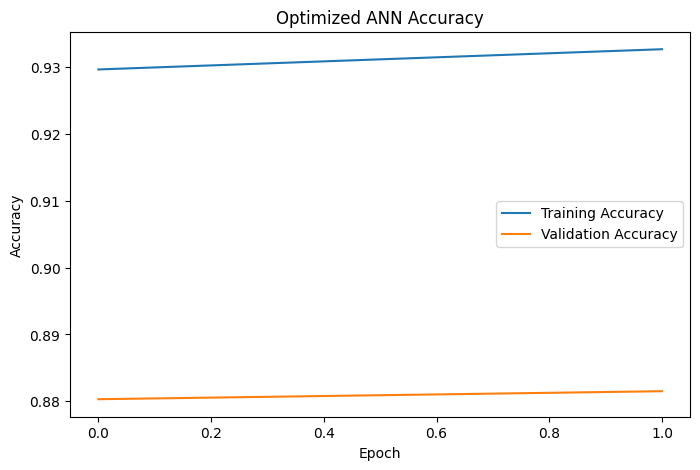

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "accuracy"
    ],

    label="Training Accuracy"
)

plt.plot(

    optimized_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"
)

plt.title(
    "Optimized ANN Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.show()

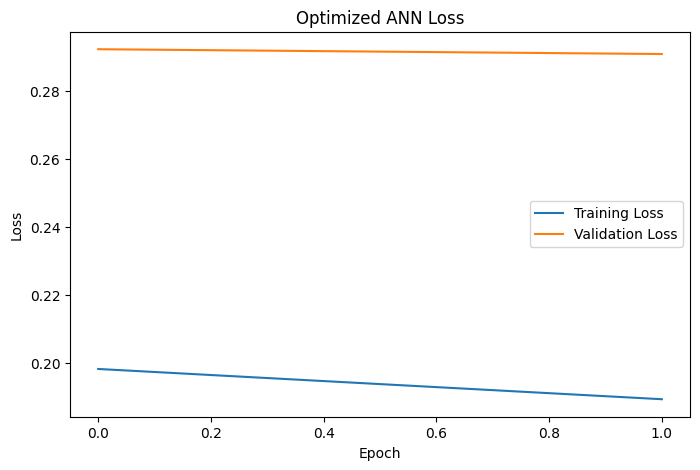

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "loss"
    ],

    label="Training Loss"
)

plt.plot(

    optimized_history.history[
        "val_loss"
    ],

    label="Validation Loss"
)

plt.title(
    "Optimized ANN Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()

In [42]:
embedding_df.to_csv(
    "saved_models/embedding_tuning.csv",
    index=False
)

hidden_df.to_csv(
    "saved_models/hidden_units_tuning.csv",
    index=False
)

dropout_df.to_csv(
    "saved_models/dropout_tuning.csv",
    index=False
)

recurrent_df.to_csv(
    "saved_models/recurrent_dropout_tuning.csv",
    index=False
)

learning_rate_df.to_csv(
    "saved_models/learning_rate_tuning.csv",
    index=False
)

optimizer_df.to_csv(
    "saved_models/optimizer_tuning.csv",
    index=False
)

batch_df.to_csv(
    "saved_models/batch_size_tuning.csv",
    index=False
)

comparison.to_csv(
    "saved_models/baseline_vs_optimized.csv",
    index=False
)

In [43]:
print("=" * 60)

print("PHASE 5 - MODEL IMPROVEMENT COMPLETED")

print("=" * 60)

print("\nBaseline ANN Accuracy:")

print(
    round(
        baseline_result["Accuracy"],
        4
    )
)

print("\nOptimized ANN Accuracy:")

print(
    round(
        optimized_result["Accuracy"],
        4
    )
)

print("\nAccuracy Improvement:")

print(
    round(
        accuracy_improvement,
        4
    )
)

print("\nBaseline F1 Score:")

print(
    round(
        baseline_result["F1 Score"],
        4
    )
)

print("\nOptimized F1 Score:")

print(
    round(
        optimized_result["F1 Score"],
        4
    )
)

print("\nF1 Improvement:")

print(
    round(
        f1_improvement,
        4
    )
)

print("\nOptimized Model Saved At:")

print(
    "saved_models/optimized_ANN.keras"
)

PHASE 5 - MODEL IMPROVEMENT COMPLETED

Baseline ANN Accuracy:
0.8465

Optimized ANN Accuracy:
0.8859

Accuracy Improvement:
0.0393

Baseline F1 Score:
0.8587

Optimized F1 Score:
0.8875

F1 Improvement:
0.0289

Optimized Model Saved At:
saved_models/optimized_ANN.keras
